# Feature Engineering

**Objective:** Transform raw transaction data into features that ML models can use effectively.

**What we'll do:**
1. Extract hour from time_elapsed
2. Apply cyclic encoding (sin/cos) to hour
3. Scale the amount feature using StandardScaler
4. Split data with stratification

## 1. Setup

In [2]:
import sys
import os
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psycopg2
from dotenv import load_dotenv

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

load_dotenv()

plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported")

Libraries imported


## 2. Load Data from Database

In [3]:
conn = psycopg2.connect(
    host=os.getenv('DB_HOST', 'localhost'),
    port=int(os.getenv('DB_PORT', 5432)),
    database=os.getenv('DB_NAME', 'fraud_detection'),
    user=os.getenv('DB_USER', 'postgres'),
    password=os.getenv('DB_PASSWORD', '')
)

df = pd.read_sql("SELECT * FROM transactions_raw", conn)
conn.close()

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

C:\Users\Dell\AppData\Local\Temp\ipykernel_4536\3778018407.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM transactions_raw", conn)


Loaded: 284,807 rows x 33 columns


## 3. Extract Time Features

**Why?** Raw `time_elapsed` is just seconds. We need "hour of day" to capture patterns like "fraud happens more at night".

In [4]:
# Extract hour (0-23) from time_elapsed
df['hour'] = ((df['time_elapsed'] / 3600) % 24).astype(int)

# Extract day (dataset covers 2 days)
df['day'] = (df['time_elapsed'] // 86400).astype(int)

print("Hours in data:", sorted(df['hour'].unique()))
print("\nSample rows:")
print(df[['time_elapsed', 'hour', 'day']].head(10))

Hours in data: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

Sample rows:
   time_elapsed  hour  day
0           0.0     0    0
1           0.0     0    0
2           1.0     0    0
3           1.0     0    0
4           2.0     0    0
5           2.0     0    0
6           4.0     0    0
7           7.0     0    0
8           7.0     0    0
9           9.0     0    0


## 4. Cyclic Encoding for Hour

**Problem:** Hour 23 and hour 0 are adjacent (midnight), but numerically far apart.

**Solution:** Convert to sin/cos to map onto a circle.

In [5]:
# Create cyclic encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Show key hours to verify they're close
key_hours = pd.DataFrame({'hour': [0, 1, 22, 23]})
key_hours['hour_sin'] = np.sin(2 * np.pi * key_hours['hour'] / 24)
key_hours['hour_cos'] = np.cos(2 * np.pi * key_hours['hour'] / 24)

print("Key hours - notice how 23 and 0 are now close:")
print(key_hours)

Key hours - notice how 23 and 0 are now close:
   hour  hour_sin  hour_cos
0     0  0.000000  1.000000
1     1  0.258819  0.965926
2    22 -0.500000  0.866025
3    23 -0.258819  0.965926


## 5. Visualize Cyclic Encoding

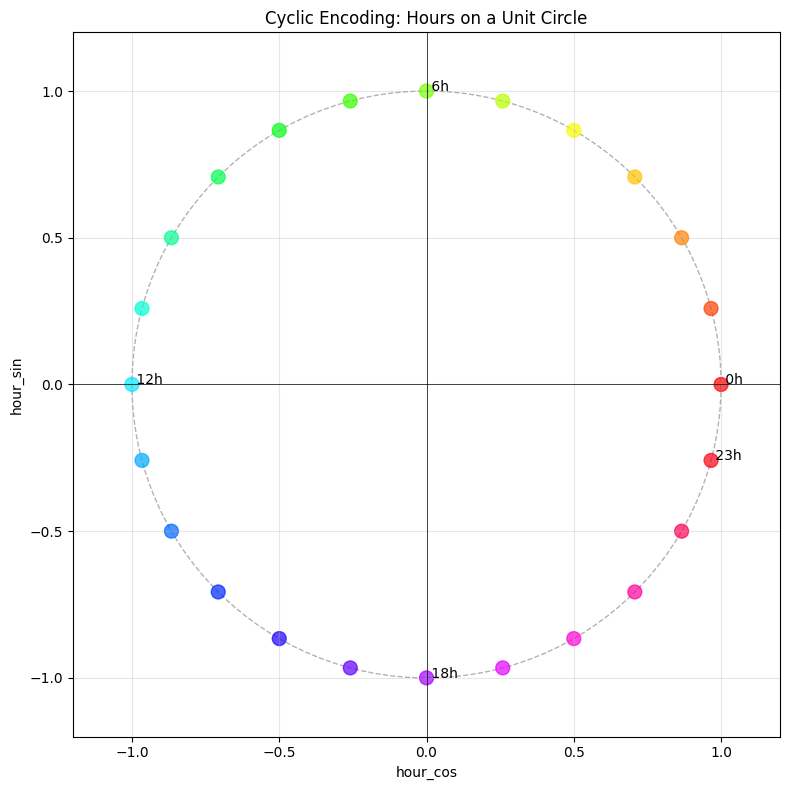

Saved: docs/images/cyclic_encoding.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

# Draw circle
circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', alpha=0.3)
ax.add_patch(circle)

# Plot all hours
scatter = ax.scatter(hour_cos, hour_sin, c=hours, cmap='hsv', s=100, alpha=0.7)

# Label key hours
for h in [0, 6, 12, 18, 23]:
    ax.text(hour_cos[h], hour_sin[h], f' {h}h', fontsize=10)

ax.set_xlabel('hour_cos')
ax.set_ylabel('hour_sin')
ax.set_title('Cyclic Encoding: Hours on a Unit Circle')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../docs/images/cyclic_encoding.png', dpi=150)
plt.show()

print("Saved: docs/images/cyclic_encoding.png")

## 6. Train/Test Split (BEFORE Scaling!)

**Critical:** Split first, then scale. This prevents data leakage.

In [7]:
# Prepare features
v_cols = [c for c in df.columns if c.startswith('v')]
feature_cols = v_cols + ['amount', 'hour_sin', 'hour_cos']

X = df[feature_cols]
y = df['class']

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} samples (Fraud: {y_train.sum():,}, {y_train.mean():.4%})")
print(f"Test: {len(X_test):,} samples (Fraud: {y_test.sum():,}, {y_test.mean():.4%})")

Train: 227,845 samples (Fraud: 394, 0.1729%)
Test: 56,962 samples (Fraud: 98, 0.1720%)


## 7. Scale Amount Feature

**Fit on train only, then transform both.**

In [8]:
scaler = StandardScaler()

# Fit on train, transform both
X_train['amount_scaled'] = scaler.fit_transform(X_train[['amount']])
X_test['amount_scaled'] = scaler.transform(X_test[['amount']])

print("=== Amount Statistics ===")
print(f"Before: Train mean=${X_train['amount'].mean():.2f}, std=${X_train['amount'].std():.2f}")
print(f"After:  Train mean={X_train['amount_scaled'].mean():.6f}, std={X_train['amount_scaled'].std():.6f}")

# Drop original amount
X_train = X_train.drop('amount', axis=1)
X_test = X_test.drop('amount', axis=1)

print(f"\nFinal shape: Train {X_train.shape}, Test {X_test.shape}")

=== Amount Statistics ===
Before: Train mean=$88.18, std=$250.72
After:  Train mean=0.000000, std=1.000002

Final shape: Train (227845, 31), Test (56962, 31)


## 8. Visualize Scaling Effect

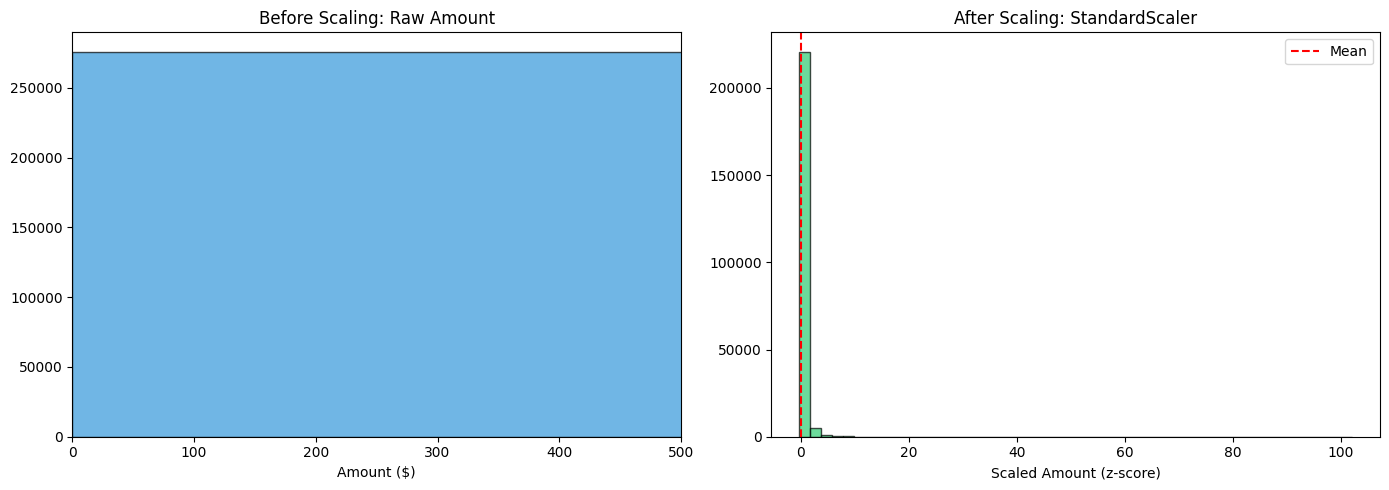

Saved: docs/images/scaling_effect.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].hist(df['amount'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].set_title('Before Scaling: Raw Amount')
axes[0].set_xlabel('Amount ($)')
axes[0].set_xlim(0, 500)

# After
axes[1].hist(X_train['amount_scaled'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1].set_title('After Scaling: StandardScaler')
axes[1].set_xlabel('Scaled Amount (z-score)')
axes[1].axvline(0, color='red', linestyle='--', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/images/scaling_effect.png', dpi=150)
plt.show()

print("Saved: docs/images/scaling_effect.png")

## 9. Save Processed Data

In [10]:
# Create directory
processed_dir = Path('../data/processed')
processed_dir.mkdir(exist_ok=True)

# Save everything
joblib.dump(X_train, processed_dir / 'X_train.pkl')
joblib.dump(X_test, processed_dir / 'X_test.pkl')
joblib.dump(y_train, processed_dir / 'y_train.pkl')
joblib.dump(y_test, processed_dir / 'y_test.pkl')
joblib.dump(scaler, processed_dir / 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), processed_dir / 'feature_names.pkl')

print("=== Saved Files ===")
for f in processed_dir.glob('*.pkl'):
    print(f"  {f.name}")

=== Saved Files ===
  feature_names.pkl
  scaler.pkl
  X_test.pkl
  X_train.pkl
  y_test.pkl
  y_train.pkl


## 10. Summary

In [11]:
print("="*60)
print("     FEATURE ENGINEERING COMPLETE")
print("="*60)
print(f"\nTotal features: {X_train.shape[1]}")
print(f"  - V1-V28 (PCA): 28")
print(f"  - amount_scaled: 1")
print(f"  - hour_sin, hour_cos: 2")
print(f"\nTrain samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"\nFiles saved to: data/processed/")
print("="*60)

     FEATURE ENGINEERING COMPLETE

Total features: 31
  - V1-V28 (PCA): 28
  - amount_scaled: 1
  - hour_sin, hour_cos: 2

Train samples: 227,845
Test samples: 56,962

Files saved to: data/processed/
